In [19]:
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt



In [20]:
sys.path.append(os.path.abspath(".."))

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold


from src.data_utils import (load_data)


In [22]:


X_train= load_data("../data/X_train_with_new_features.csv")
y_train= load_data("../data/y_train_new.csv")

DataFrame successfully loaded.
Shape: (47046, 76)
DataFrame successfully loaded.
Shape: (47046, 1)


In [23]:
X_test= load_data("../data/X_test_with_new_features.csv")
y_test= load_data("../data/y_test_new.csv")


DataFrame successfully loaded.
Shape: (11762, 76)
DataFrame successfully loaded.
Shape: (11762, 1)


In [24]:
test_df = load_data("../data/competition_test_with_new_features.csv")

DataFrame successfully loaded.
Shape: (14850, 76)


In [25]:
X_train.select_dtypes(include="object").columns

Index([], dtype='str')

In [27]:
estimator = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
)

In [28]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [29]:
rfecv = RFECV(
    estimator=estimator,
    step=1,                # removes 1 feature per iteration
    cv=cv,
    scoring="f1_macro",    # IMPORTANT for imbalance
    n_jobs=-1              # speeds it up
)

In [30]:
rfecv.fit(X_train, y_train)

/Users/emerie/Desktop/RediStuffs/DataC/PumpHealth/venv/Pumphealth_venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/emerie/Desktop/RediStuffs/DataC/PumpHealth/venv/Pumphealth_venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/emerie/Desktop/RediStuffs/DataC/PumpHealth/venv/Pumphealth_venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/emerie/Desktop/RediStuff

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LogisticRegre...max_iter=1000)
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",'f1_macro'
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",-1
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must b

In [31]:
selected_features = X_train.columns[rfecv.support_]
print("Number of selected features:", len(selected_features))
print(selected_features)

Number of selected features: 75
Index(['longitude', 'latitude', 'amount_tsh_log', 'population_log', 'pump_age',
       'pump_is_new', 'pump_age_band', 'height_band', 'quantity_score',
       'is_paid_water', 'is_water_safe', 'lga_te', 'basin_Internal',
       'basin_Lake Nyasa', 'basin_Lake Rukwa', 'basin_Lake Tanganyika',
       'basin_Lake Victoria', 'basin_Pangani', 'basin_Rufiji',
       'basin_Ruvuma / Southern Coast', 'basin_Wami / Ruvu',
       'public_meeting_False', 'public_meeting_True', 'permit_False',
       'permit_True', 'quantity_dry', 'quantity_enough',
       'quantity_insufficient', 'quantity_seasonal', 'payment_never pay',
       'payment_other', 'payment_pay annually', 'payment_pay monthly',
       'payment_pay per bucket', 'payment_pay when scheme fails',
       'extraction_type_afridev', 'extraction_type_gravity',
       'extraction_type_india mark ii', 'extraction_type_ksb',
       'extraction_type_mono', 'extraction_type_nira/tanira',
       'extraction_type_oth

In [32]:
X_selected = X_train[selected_features]

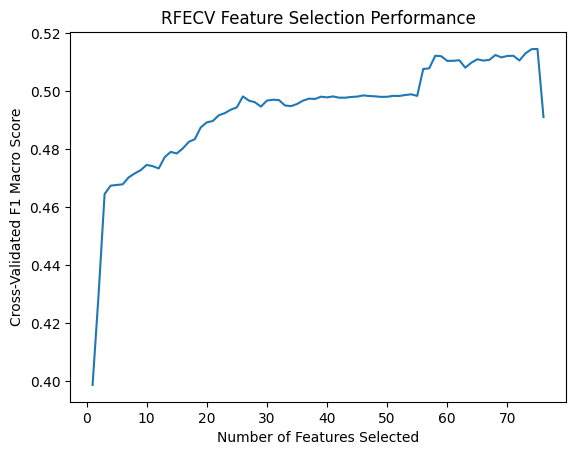

In [33]:

plt.plot(range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
         rfecv.cv_results_["mean_test_score"])

plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validated F1 Macro Score")
plt.title("RFECV Feature Selection Performance")
plt.show()

In [38]:


model = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)

model.fit(X_selected, y_train)

/Users/emerie/Desktop/RediStuffs/DataC/PumpHealth/venv/Pumphealth_venv/lib/python3.13/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [40]:
X_selected_test = X_test[selected_features]

In [42]:
y_pred_rf = model.predict(X_selected_test)

In [43]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.787451113756164
                         precision    recall  f1-score   support

             functional       0.80      0.87      0.83      6384
functional needs repair       0.46      0.30      0.36       848
         non functional       0.81      0.77      0.79      4530

               accuracy                           0.79     11762
              macro avg       0.69      0.64      0.66     11762
           weighted avg       0.78      0.79      0.78     11762



In [44]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    eval_metric="mlogloss"
    )

model.fit(X_selected, y_train_enc)

y_pred_xgb = model.predict(X_selected_test)

print("Accuracy:", accuracy_score(y_test_enc, y_pred_xgb))
print(classification_report(y_test_enc, y_pred_xgb, target_names=le.classes_))

/Users/emerie/Desktop/RediStuffs/DataC/PumpHealth/venv/Pumphealth_venv/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/emerie/Desktop/RediStuffs/DataC/PumpHealth/venv/Pumphealth_venv/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


Accuracy: 0.7960380887604149
                         precision    recall  f1-score   support

             functional       0.78      0.90      0.84      6384
functional needs repair       0.55      0.25      0.35       848
         non functional       0.84      0.75      0.79      4530

               accuracy                           0.80     11762
              macro avg       0.73      0.63      0.66     11762
           weighted avg       0.79      0.80      0.79     11762



In [12]:
y_pred_competition = model.predict(test_df)

y_pred_labels = le.inverse_transform(y_pred_competition)

In [13]:
submission = pd.read_csv("../data/SubmissionFormat.csv")


In [14]:
submission["status_group"] = y_pred_labels


In [15]:
submission.to_csv("../data/submission.csv", index=False)

print("Submission file created successfully.")
print(submission.head())

Submission file created successfully.
      id    status_group
0  50785      functional
1  51630      functional
2  17168      functional
3  45559  non functional
4  49871      functional


In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    eval_metric="mlogloss"
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X_train,
    y_train_enc,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print(scores)
print(scores.mean())

[0.80085016 0.79466468 0.79838453 0.79349559 0.78913806]
0.795306603248817


# full train

In [17]:
X_full = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

le = LabelEncoder()
y_full_enc = le.fit_transform(y_full.values.ravel())

final_model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    eval_metric="mlogloss"
)

final_model.fit(X_full, y_full_enc)

train_preds = final_model.predict(X_full)

print("Training Accuracy:", accuracy_score(y_full_enc, train_preds))
print(classification_report(y_full_enc, train_preds, target_names=le.classes_))

Training Accuracy: 0.8369949666712012
                         precision    recall  f1-score   support

             functional       0.81      0.94      0.87     31920
functional needs repair       0.76      0.35      0.48      4240
         non functional       0.89      0.79      0.83     22648

               accuracy                           0.84     58808
              macro avg       0.82      0.69      0.73     58808
           weighted avg       0.84      0.84      0.83     58808



In [18]:

final_preds = final_model.predict(test_df)

final_preds_labels = le.inverse_transform(final_preds)

submission = pd.read_csv("../data/SubmissionFormat.csv")

submission["status_group"] = final_preds_labels

submission.to_csv("../data/submission_fulltrain.csv", index=False)

print("submission_fulltrain.csv created successfully.")

submission_fulltrain.csv created successfully.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Models and metrics
models = ["Model 1", "Model 2"]
accuracy = [0.7878, 0.7958]
macro_f1 = [0.66, 0.66]

x = np.arange(len(models))
width = 0.35

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

# Bars
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy')
bars2 = ax.bar(x + width/2, macro_f1, width, label='Macro F1')

# Labels and title
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.legend()

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()